In [1]:
pip install EMD-signal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [ ]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

In [5]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [6]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [7]:
df_raw_data = pd.read_csv('Indonesia-DroughtPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 cdd（推荐做法），构造与模板一致的 Series 写法
series_close = pd.Series(
    df_raw_data['cdd'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['cdd'].values提取'cdd'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01    4.43
1950-02-01    1.75
1950-03-01    1.42
1950-04-01    0.96
1950-05-01    2.36
              ... 
2023-08-01    8.38
2023-09-01    8.54
2023-10-01    8.86
2023-11-01    3.13
2023-12-01    1.55
Length: 888, dtype: float64


In [8]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [10]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

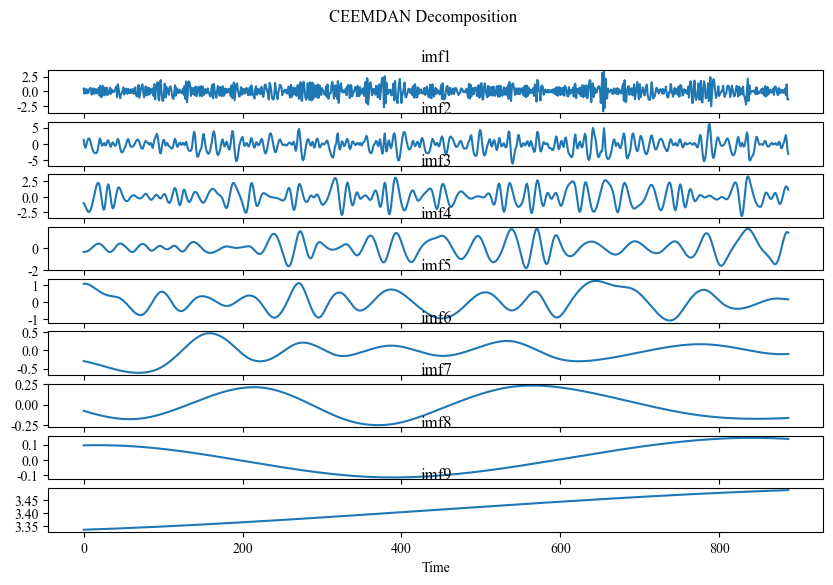

In [11]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [13]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-INDONESIA-CDD.xlsx",index=False)
#保存数据为CEEMDAN-CHINA-CDD.xlsx

         imf1      imf2      imf3      imf4      imf5      imf6      imf7  \
0    0.453113  1.219873 -1.017579 -0.365456  1.079525 -0.294651 -0.076950   
1   -0.427692 -0.362094 -1.230654 -0.367358  1.084277 -0.298896 -0.079916   
2    0.377510 -1.230365 -1.495622 -0.362086  1.084181 -0.303292 -0.082857   
3   -0.334297 -0.686922 -1.788334 -0.348829  1.079264 -0.307834 -0.085774   
4    0.326085  0.328835 -2.069431 -0.327073  1.069850 -0.312516 -0.088665   
..        ...       ...       ...       ...       ...       ...       ...   
883  0.431754  1.813929  1.420888  1.173607  0.182547 -0.104526 -0.166305   
884 -0.657360  2.692003  1.639457  1.329421  0.178204 -0.103779 -0.165874   
885  1.181749  1.091574  1.635740  1.417253  0.174273 -0.102899 -0.165434   
886 -1.407873 -1.872078  1.450596  1.427784  0.170891 -0.101888 -0.164984   
887 -1.413083 -3.066584  1.133158  1.366262  0.168168 -0.100749 -0.164525   

         imf8      imf9  
0    0.095330  3.336796  
1    0.095431  3.336901